In [7]:
import pickle

from IPython.extensions.deduperreload.deduperreload_patching import NULL
from shap import Explanation
import shap
import json
from matplotlib import pyplot as plt
import numpy as np
import joblib
import pandas as pd
import numpy as np
from utils import DataProcessor

In [8]:
import pickle
with open('catboost/shap_explanation.pkl', 'rb') as f:
    cat_explanation = pickle.load(f)

with open('xgboost/shap_explanation.pkl', 'rb') as f:
    xgb_explanation = pickle.load(f)

with open('lightgbm/shap_explanation.pkl', 'rb') as f:
    lgb_explanation = pickle.load(f)

data = DataProcessor("../hyper_wheat_ds_ch_norm_prep_mode=dai.csv").split_data()

# Интерпретация предсказания для одного объекта в тестовой выборке

Выводит только те признаки, которые имеют все более 5%, этот параметр можно поменять(contribution_threshold)

In [9]:
cat_explanation_base = round((cat_explanation.base_values).mean(), 3)
xgb_explanation_base = round((xgb_explanation.base_values).mean(), 3)
lgb_explanation_base = round((lgb_explanation.base_values).mean(), 3)
print("Базовое предсказание модели", round((cat_explanation.base_values).mean(), 3))
print("Базовое предсказание модели", round((xgb_explanation.base_values).mean(), 3))
print("Базовое предсказание модели", round((lgb_explanation.base_values).mean(), 3))

Базовое предсказание модели 0.058
Базовое предсказание модели -0.005
Базовое предсказание модели 0.29


# Интерпретация предсказаний

### Сравнение интерпретации одного объекта для нескольких моделей

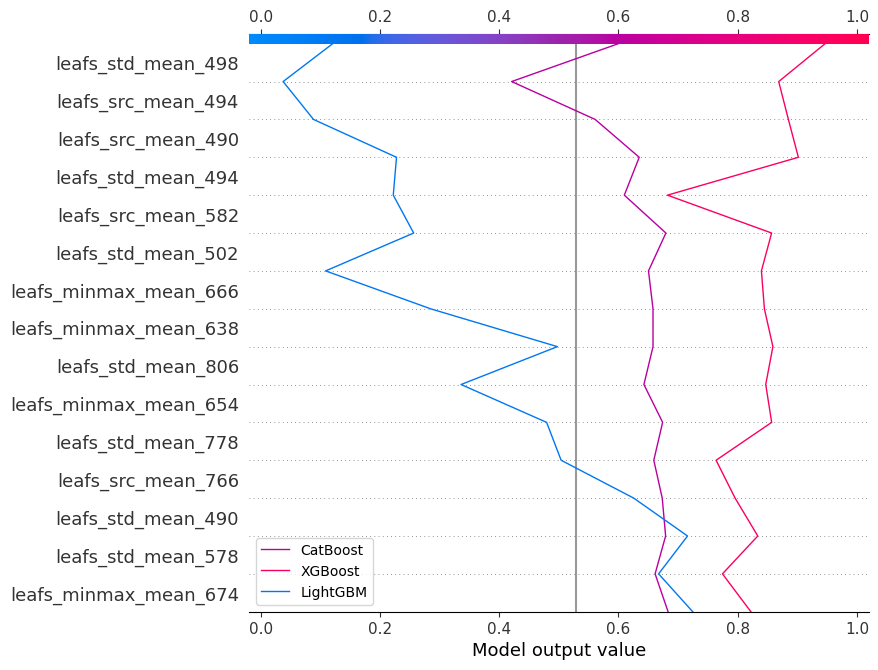

In [10]:
object = 2
base_values = [
    cat_explanation.base_values[object],
    xgb_explanation.base_values[object],
    lgb_explanation.base_values[object]]
shap_arrays = [
    cat_explanation.values,
    xgb_explanation.values,
    lgb_explanation.values]
feature_values = cat_explanation.data[object]
feature_names = cat_explanation.feature_names
shap.multioutput_decision_plot(
    base_values,
    shap_arrays,
    row_index=object,
    feature_display_range=slice(-1, -16, -1),
    feature_names=feature_names,
    link='logit',
    legend_labels=['CatBoost', 'XGBoost', 'LightGBM'])

Сравнение глобальной важности признако для всех моделей

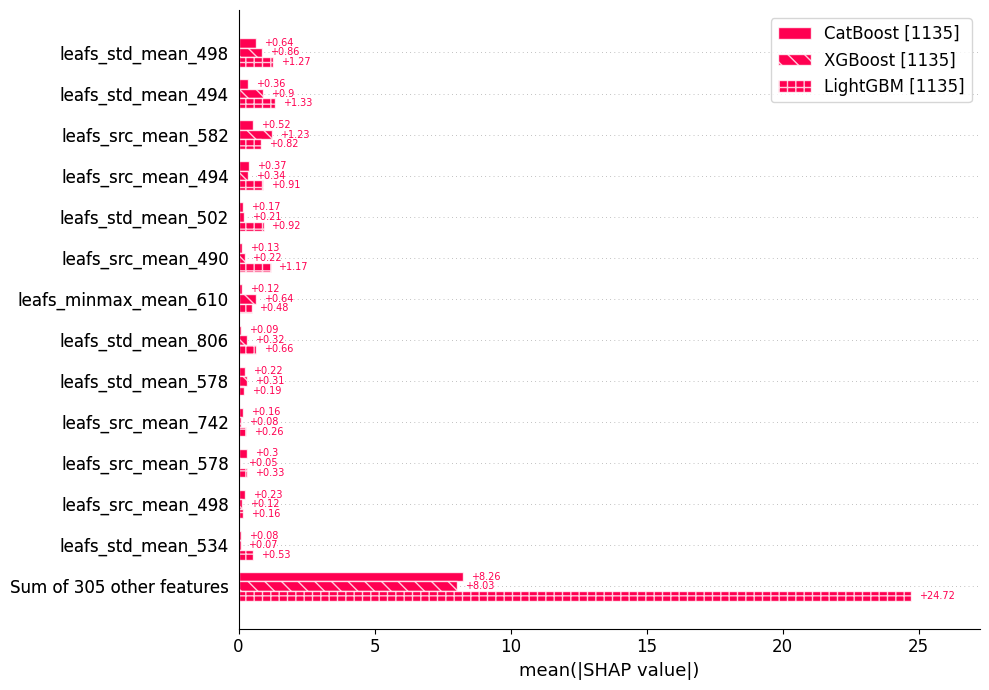

In [11]:
cohorts_local = {
    "CatBoost": cat_explanation,
    "XGBoost": xgb_explanation,
    "LightGBM": lgb_explanation
}
ax = shap.plots.bar(cohorts_local, max_display=14, show=False)
ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=12)
ax.legend(fontsize=12)
for text in ax.texts:
    text.set_fontsize(7)

fig = ax.figure
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

# Топ-15 самый важных признаков ансамблевых методов

In [12]:
#Создание Datafraim, чтобы выделить n важных признаков из explaration
# Суммируем абсолютные SHAP-значения по всем объектам
df_all = pd.DataFrame({
    'feature': cat_explanation.feature_names,
    'catboost': np.abs(cat_explanation.values).mean(axis=0),
    'xgboost': np.abs(xgb_explanation.values).mean(axis=0),
    'lightgbm': np.abs(lgb_explanation.values).mean(axis=0)
})

df_all["sum_shaple"] = df_all[['catboost', 'xgboost', 'lightgbm']].sum(axis=1)
df_all = df_all.sort_values('sum_shaple', ascending=False)

print(df_all.head(15))
top_feature = df_all.head(20)["feature"].tolist()
data.top_feature = top_feature

with open('top_features.json', 'w') as f:
    json.dump(top_feature, f)

                   feature  catboost   xgboost  lightgbm  sum_shaple
224     leafs_std_mean_498  0.642616  0.855255  1.265334    2.763206
223     leafs_std_mean_494  0.363857  0.895401  1.328470    2.587729
33      leafs_src_mean_582  0.524635  1.231041  0.818087    2.573763
222     leafs_std_mean_490  0.018661  0.430875  1.575631    2.025168
11      leafs_src_mean_494  0.370679  0.336671  0.910875    1.618225
10      leafs_src_mean_490  0.132455  0.217258  1.172874    1.522587
225     leafs_std_mean_502  0.169763  0.213337  0.917523    1.300623
146  leafs_minmax_mean_610  0.121633  0.639387  0.475912    1.236932
301     leafs_std_mean_806  0.091644  0.318384  0.657464    1.067493
240     leafs_std_mean_562  0.029764  0.107965  0.852266    0.989996
294     leafs_std_mean_778  0.029409  0.383118  0.484619    0.897146
79      leafs_src_mean_766  0.035236  0.368379  0.478962    0.882576
145  leafs_minmax_mean_606  0.051727  0.043387  0.637202    0.732316
244     leafs_std_mean_578  0.2228